In [357]:
print("hlo")

hlo


In [358]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as warning
warning.filterwarnings("ignore")

# Problem Satement :- Detecting spam or Not

## Getting the dataset (From Kaggle)

In [359]:
data=pd.read_csv("spam_dataset.csv")
df=pd.DataFrame(data)

In [360]:
df.head(5) #First Look of data 

,message_content,is_spam
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0
1,"Congratulations, you've won a prize! Call us n...",1
2,You have been pre-approved for a credit card w...,1
3,"Limited time offer, act now! Only a few spots ...",1
4,Your loan has been approved! Transfer funds to...,1


## EDA

### Basic Structure

In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   message_content  1000 non-null   object
 1   is_spam          1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [362]:
# Shape 

df.shape   #1000 Documents and 2 Features

(1000, 2)

In [363]:
# Size

df.size #Total value in Corpus

2000

In [364]:
# Null Values

df.isnull().sum() #No null values in corpus

message_content    0
is_spam            0
dtype: int64

In [365]:
df.duplicated().sum()  #Total 323 Duplicate values

np.int64(323)

### Target Variables Analysis

In [366]:
df["is_spam"].value_counts() #Count of values in is_spam feature

is_spam
0    500
1    500
Name: count, dtype: int64

In [367]:
df["is_spam"].value_counts(normalize=True)*100 #Percentage Distribution of data  

is_spam
0    50.0
1    50.0
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

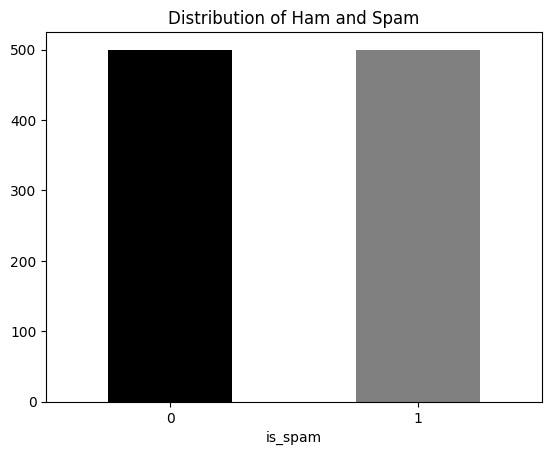

In [368]:
df.is_spam.value_counts().plot(kind='bar',color=["black","grey"])
plt.xticks(rotation=0)
plt.title("Distribution of Ham and Spam")
plt.show

### Text Length Analysis

In [369]:
def relen(txt):
    return len(txt)

In [370]:
df["message_content"].astype("str")
df["messg_len"]=df["message_content"].apply(relen) # count of characters of message_content

In [371]:
df.head(5)

,message_content,is_spam,messg_len
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,392
1,"Congratulations, you've won a prize! Call us n...",1,204
2,You have been pre-approved for a credit card w...,1,215
3,"Limited time offer, act now! Only a few spots ...",1,189
4,Your loan has been approved! Transfer funds to...,1,198


In [372]:
df.head(5)

,message_content,is_spam,messg_len
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,392
1,"Congratulations, you've won a prize! Call us n...",1,204
2,You have been pre-approved for a credit card w...,1,215
3,"Limited time offer, act now! Only a few spots ...",1,189
4,Your loan has been approved! Transfer funds to...,1,198


In [373]:
def lenword(txt):
    return len(txt.split())

In [374]:
df["word_len"]=df["message_content"].apply(lenword)

In [375]:
print(df.groupby("is_spam")["word_len"].describe())

         count    mean       std   min   25%   50%   75%   max
is_spam                                                       
0        500.0  71.050  6.561219  51.0  67.0  71.0  76.0  86.0
1        500.0  32.746  2.564886  27.0  31.0  33.0  35.0  38.0


Text(0.5, 1.0, 'Count of Words')

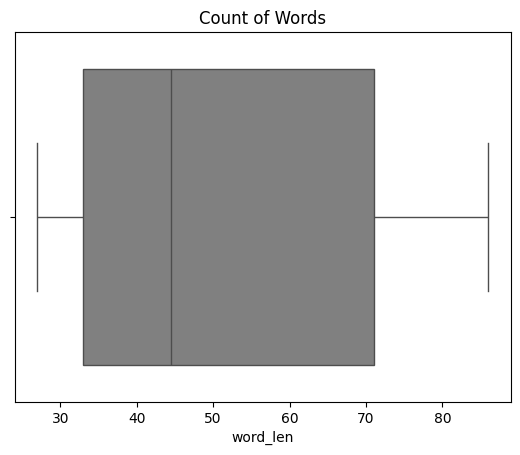

In [376]:
sns.boxplot(x=df["word_len"],color="grey")
plt.title("Count of Words")

### Word-Level Analysis

In [377]:
from collections import Counter
hum_word=" ".join(df[df["is_spam"]==0]["message_content"]).lower().split()
spam_word=" ".join(df[df["is_spam"]==1]["message_content"]).lower().split()

hum_common=Counter(hum_word).most_common(20)
spam_common=Counter(spam_word).most_common(20)

In [378]:
print("Most common Ham words : ")
print(hum_common)
print("Most common spam words : ")
print(spam_common)

Most common Ham words : 
[('you', 1380), ('to', 1221), ('please', 1035), ('the', 908), ('any', 885), ('have', 802), ('if', 760), ('your', 607), ('out.', 603), ('reach', 577), ('free', 575), ('feel', 574), ('questions,', 565), ('i', 549), ('attached', 327), ('on', 286), ('let', 285), ('know', 284), ('me', 249), ('for', 232)]
Most common spam words : 
[('for', 763), ('to', 693), ('our', 551), ('us', 518), ('contact', 516), ('more', 500), ('details,', 500), ('visit', 500), ('website', 500), ('or', 500), ('directly.', 500), ('your', 483), ('a', 356), ('this', 296), ('click', 251), ('act', 246), ('now', 197), ('been', 183), ('limited', 176), ('account', 171)]


### Special Patterns Check

In [379]:
# Check is there is numerical data in corpus in message_content

def is_num(txt):
    ans=0
    for i in txt:
        if(i.isdigit()):
            ans=1
    return ans

In [380]:
df["Num_in_message"]=df["message_content"].apply(is_num)

In [381]:
df.head(5)

,message_content,is_spam,messg_len,word_len,Num_in_message
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,392,60,0
1,"Congratulations, you've won a prize! Call us n...",1,204,36,0
2,You have been pre-approved for a credit card w...,1,215,38,0
3,"Limited time offer, act now! Only a few spots ...",1,189,30,0
4,Your loan has been approved! Transfer funds to...,1,198,32,0


In [382]:
df[df["Num_in_message"]==1].shape # Total 161 Documents have Numbers in message_content

(161, 5)

In [383]:
def count_excalmation(txt):
    count=0
    for i in txt:
        if i=="!":
            count+=1
    return count

In [384]:
df["count_exclamation"]=df["message_content"].apply(count_excalmation) #Because spam message's have high number of exclamation mark

In [385]:
df.head(5)

,message_content,is_spam,messg_len,word_len,Num_in_message,count_exclamation
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,392,60,0,0
1,"Congratulations, you've won a prize! Call us n...",1,204,36,0,2
2,You have been pre-approved for a credit card w...,1,215,38,0,0
3,"Limited time offer, act now! Only a few spots ...",1,189,30,0,2
4,Your loan has been approved! Transfer funds to...,1,198,32,0,3


### Corelation Check 

In [386]:
numerical_col=["messg_len","word_len","count_exclamation"]
corr_matrix=df[numerical_col].corr()

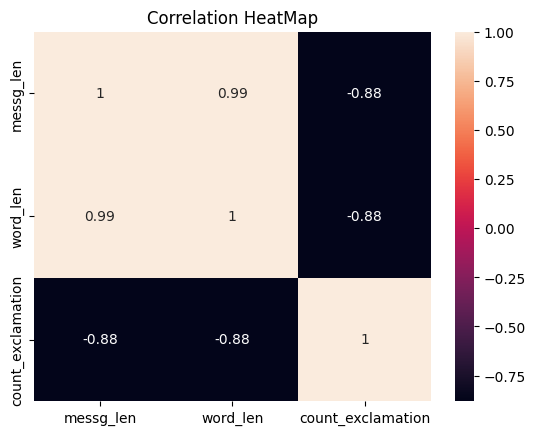

In [387]:
# Heat Map
plt.title("Correlation HeatMap")
sns.heatmap(corr_matrix,annot=True)
plt.show()

#### Removing the duplicated data in df

In [388]:
dup_i=df[df["message_content"].duplicated()==1].index

In [389]:
df=df.drop_duplicates(subset="message_content")

In [390]:
df.shape

(677, 6)

In [391]:
df.head(5).reset_index()

,index,message_content,is_spam,messg_len,word_len,Num_in_message,count_exclamation
0,0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,392,60,0,0
1,1,"Congratulations, you've won a prize! Call us n...",1,204,36,0,2
2,2,You have been pre-approved for a credit card w...,1,215,38,0,0
3,3,"Limited time offer, act now! Only a few spots ...",1,189,30,0,2
4,4,Your loan has been approved! Transfer funds to...,1,198,32,0,3


#### Balance of the data

In [392]:
round(df["is_spam"].value_counts(normalize=True)*100,2)# 73% data is not spam and 26% is spam 

is_spam
0    73.86
1    26.14
Name: proportion, dtype: float64

## Spliting the data

In [393]:
# Due to messg_len feature the model is genralisnig the data not learning 
# so we remove the messg_len feature

df=df.drop(columns=["messg_len"],axis=1)
df.head(5)

,message_content,is_spam,word_len,Num_in_message,count_exclamation
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,60,0,0
1,"Congratulations, you've won a prize! Call us n...",1,36,0,2
2,You have been pre-approved for a credit card w...,1,38,0,0
3,"Limited time offer, act now! Only a few spots ...",1,30,0,2
4,Your loan has been approved! Transfer funds to...,1,32,0,3


In [394]:
x=df.drop(columns=["is_spam"],axis=1)
y=df["is_spam"]

In [395]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

### No Null Values 

In [396]:
x_train

,message_content,word_len,Num_in_message,count_exclamation
241,"This is not a scam, click now to see the detai...",33,0,2
249,"Hi Kimberly,\n\nThank you for your email. I wi...",69,0,0
11,"Hi Joe,\n\nJust a quick reminder about our sch...",66,1,0
521,"Hey Jennifer,\n\nIt was great speaking with yo...",76,0,0
592,"Hi Carl,\n\nJust a reminder about the deadline...",80,1,0
...,...,...,...,...
215,Earn money from home! No experience needed.\n\...,27,0,2
30,"Congratulations, you've won a prize! Call us n...",31,0,2
964,"Hi Mary,\n\nJust a quick reminder about our sc...",74,1,0
112,Hot singles in your area want to chat! Contact...,37,0,1


### Outliers Detection

<Axes: xlabel='word_len'>

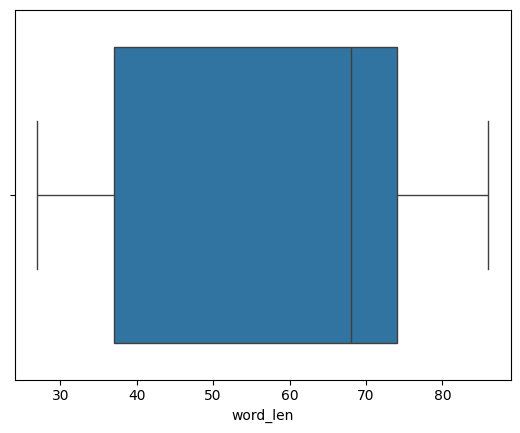

In [397]:
sns.boxplot(x=x_train["word_len"])

In [398]:
per_25=df["word_len"].quantile(0.25)
per_75=df["word_len"].quantile(0.75)

In [399]:
per_25,per_75

(np.float64(37.0), np.float64(74.0))

In [400]:
Iqr=per_75-per_25

In [401]:
lower_limit=Iqr-1.5*per_25
upper_limit=Iqr+1.5*per_75

In [402]:
upper_limit,lower_limit

(np.float64(148.0), np.float64(-18.5))

In [403]:
outliers=df[(df["word_len"]>upper_limit)|(df["word_len"]<lower_limit)] # No outliers
outliers.shape

(0, 5)

In [404]:
df["word_len"].max(),df["word_len"].min() # Min and Max values are between upper and lower limit (so there are no outliers)

(np.int64(86), np.int64(27))

Hence there are no outliers in the non duplicated dataset

## Text Cleaning

In [405]:
df.head(5)

,message_content,is_spam,word_len,Num_in_message,count_exclamation
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,60,0,0
1,"Congratulations, you've won a prize! Call us n...",1,36,0,2
2,You have been pre-approved for a credit card w...,1,38,0,0
3,"Limited time offer, act now! Only a few spots ...",1,30,0,2
4,Your loan has been approved! Transfer funds to...,1,32,0,3


In [406]:
# remove Pantuation
import string
def remove_punc(txt):
    return txt.translate(str.maketrans(" "," ",string.punctuation))

#Remove numbers
def remove_num(txt):
    new=""
    for i in txt:
        if not (i.isdigit()):
            new+=i
    return new

#Remove urls

#Remove Emojis
def remove_emojis(txt):
    new=""
    for i in txt:
        if i.isascii():
            new+=i
    return new

#Remove Stop words
import nltk
from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))

def remove_stopwrds(txt):
    words=txt.split()
    cleaned=[]

    for i in words:
        if not i in stop_words:
            cleaned.append(i)
    return " ".join(cleaned)


#main(txt cleaning)
def txtclean(txt):
    txt=txt.lower()
    txt=remove_punc(txt)
    txt=remove_num(txt)
    txt=remove_emojis(txt)
    txt=remove_stopwrds(txt)

    return txt

In [407]:
# Doin Text cleaning in dataframe
x_train["message_content"]=x_train["message_content"].apply(txtclean)
x_test["message_content"]=x_test["message_content"].apply(txtclean)


In [408]:
x_train.head(5)

,message_content,word_len,Num_in_message,count_exclamation
241,scam click see details get instant access prem...,33,0,2
249,hi kimberly thank email get back detailed resp...,69,0,0
11,hi joe quick reminder scheduled meeting tomorr...,66,1,0
521,hey jennifer great speaking look forward next ...,76,0,0
592,hi carl reminder deadline report submission pl...,80,1,0


In [409]:
df.head(5)

,message_content,is_spam,word_len,Num_in_message,count_exclamation
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0,60,0,0
1,"Congratulations, you've won a prize! Call us n...",1,36,0,2
2,You have been pre-approved for a credit card w...,1,38,0,0
3,"Limited time offer, act now! Only a few spots ...",1,30,0,2
4,Your loan has been approved! Transfer funds to...,1,32,0,3


## Preprocessing

In [410]:
# Converting words in vector form
from sklearn.feature_extraction.text import TfidfVectorizer
vector=TfidfVectorizer(max_features=3000)

x_train_tfid=vector.fit_transform(x_train["message_content"])
x_test_tfid=vector.transform(x_test["message_content"])

In [411]:
df.columns

Index(['message_content', 'is_spam', 'word_len', 'Num_in_message',
       'count_exclamation'],
      dtype='object')

In [412]:
#Scaling the numeric data
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
numerical_col=["word_len","Num_in_message","count_exclamation"]
x_trainscaled=scaler.fit_transform(x_train[numerical_col])
x_testscaled=scaler.transform(x_test[numerical_col])

In [413]:
from scipy.sparse import hstack
x_train_final=hstack([x_train_tfid,x_trainscaled])
x_test_final=hstack([x_test_tfid,x_testscaled])

In [414]:
x_train_final.shape,x_test_final.shape

((541, 1575), (136, 1575))

## Model 

In [415]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
model_lr=LogisticRegression()
model_nb=MultinomialNB()

model_lr.fit(x_train_final,y_train)
model_nb.fit(x_train_final,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [416]:
y_predlr=model_lr.predict(x_test_final)
y_prednb=model_nb.predict(x_test_final)

In [417]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_predlr,y_test))
print(accuracy_score(y_prednb,y_test))


1.0
1.0


In [418]:
model_lr.score(x_train_final,y_train),model_lr.score(x_test_final,y_test)

(1.0, 1.0)

In [419]:
model_nb.score(x_train_final,y_train),model_nb.score(x_test_final,y_test)

(1.0, 1.0)

In [420]:
from sklearn.model_selection import cross_val_score
score_lr=cross_val_score(model_lr,x_train_final,y_train,cv=5)
score_nb=cross_val_score(model_nb,x_train_final,y_train,cv=7)

print(score_lr)
print(score_nb)

[1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1.]


In [421]:
# ONLY FOR NON NUMERICAL DATA
# x_train_tfid
# now
model_lr.fit(x_train_tfid,y_train)
y_pred=model_lr.predict(x_test_tfid)
print(accuracy_score(y_pred,y_test))

1.0


In [429]:
from sklearn.metrics import classification_report
y_pred = model_lr.predict(x_test_tfid)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        36

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [431]:
train_set = set(x_train['message_content'])
test_set = set(x_test['message_content'])
overlap = train_set.intersection(test_set)
print("Overlapping cleaned messages:", len(overlap))
print("Test set size:", len(test_set))
print("Overlap %:", len(overlap)/len(test_set)*100)

Overlapping cleaned messages: 0
Test set size: 136
Overlap %: 0.0


0
0


Unique predictions: (array([0, 1]), array([100,  36]))


<class 'pandas.core.frame.DataFrame'>
                                       message_content  word_len  \
241  scam click see details get instant access prem...        33   
249  hi kimberly thank email get back detailed resp...        69   
11   hi joe quick reminder scheduled meeting tomorr...        66   

     Num_in_message  count_exclamation  
241               0                  2  
249               0                  0  
11                1                  0  


Empty strings: 0
Nulls: 0
0    Hello Lonnie,\n\nJust wanted to touch base reg...
1    Congratulations, you've won a prize! Call us n...
2    You have been pre-approved for a credit card w...
3    Limited time offer, act now! Only a few spots ...
4    Your loan has been approved! Transfer funds to...
5    You have been selected to receive a special of...
6    Hello Christian,\n\nJust wanted to touch base ...
7    Dear Bethany,\n\nI hope you’re doing well. I j...
8    Free vacation, no strings attached! Book now a...
9    Claim your free gift now! Limited time offer.\...
Name: message_content, dtype: object
